**When working on "Digit Recognizer" competition without neural networks, it might be useful to add the number of rings (e.g. (1,2,3,5,7)->0, (0,4,6,9)->1, (8)->2 if written as it is) of each digit.**

**For example, it will be helpful when telling 3 and 8 apart.**

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


Import necessary modules.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Load data for evaluation.

In [3]:
train=pd.read_csv('/kaggle/input/digit-recognizer/train.csv')

Ring_counting algorithm

In [4]:
class RingCounter():
    def search(self,i,array,threshold=0):
        proximal=[]
        if i==0:
            if array[i+1]<=threshold:proximal.append(i+1)
            if array[i+28]<=threshold:proximal.append(i+28)
        elif i==27:
            if array[i-1]<=threshold:proximal.append(i-1)
            if array[i+28]<=threshold:proximal.append(i+28)
        elif i==756:
            if array[i+1]<=threshold:proximal.append(i+1)
            if array[i-28]<=threshold:proximal.append(i-28)
        elif i==783:
            if array[i-1]<=threshold:proximal.append(i-1)
            if array[i-28]<=threshold:proximal.append(i-28)
        elif i>0 and i<756 and i//28==i/28:
            if array[i-28]<=threshold:proximal.append(i-28)
            if array[i+1]<=threshold:proximal.append(i+1)
            if array[i+28]<=threshold:proximal.append(i+28)
        elif i>27 and i<783 and (i+1)//28==(i+1)/28:
            if array[i-28]<=threshold:proximal.append(i-28)
            if array[i-1]<=threshold:proximal.append(i-1)
            if array[i+28]<=threshold:proximal.append(i+28)
        elif i>0 and i<27:
            if array[i-1]<=threshold:proximal.append(i-1)
            if array[i+1]<=threshold:proximal.append(i+1)
            if array[i+28]<=threshold:proximal.append(i+28)
        elif i>756 and i<783:
            if array[i-28]<=threshold:proximal.append(i-28)
            if array[i-1]<=threshold:proximal.append(i-1)
            if array[i+1]<=threshold:proximal.append(i+1)
        else:
            if array[i-28]<=threshold:proximal.append(i-28)
            if array[i-1]<=threshold:proximal.append(i-1)
            if array[i+1]<=threshold:proximal.append(i+1)
            if array[i+28]<=threshold:proximal.append(i+28)
        
        return proximal

    def remover(self,list_1,list_2):
        list_1.extend(list_2)
        list_1,list_2=list(set(list_1)),list(set(list_2))
        try:
            for k in list_2:
                list_1.remove(k)
        except:pass
        return list_1

    def recognizer(self,row,threshold=0,min_block=9):
        array=np.array(row)
        zeros=np.where(array<=threshold)[0]
        zeros=zeros.tolist()
        ring_count=0
    
        while True:
            proximal=[]
            k=zeros[0]
            proximal.append(k)
            p_prox=self.search(k,array,threshold=threshold)
            proximal.extend(p_prox)
            new_prox=proximal.copy()

            while True:
                prox_stock=[]
                for k in new_prox:
                    p_prox=self.search(k,array,threshold=threshold)
                    prox_stock.extend(p_prox)

                new_prox=self.remover(prox_stock,proximal)
                proximal.extend(prox_stock)
                proximal=list(set(proximal))

                if new_prox==[]:
                    if  len(proximal)==len(zeros):
                        return ring_count
                        break
                    elif self.remover(zeros,proximal)!=[]:
                        if len(proximal)>=min_block:
                            ring_count+=1
                            zeros=self.remover(zeros,proximal)
                            break
                        else:
                            zeros=self.remover(zeros,proximal)
                            break
                    else:
                        return ring_count
                        break
                else:
                    pass

Evaluation with some train data.

Recognizer result: 2
Label: 8


Recognizer result: 1
Label: 9


Recognizer result: 0
Label: 1




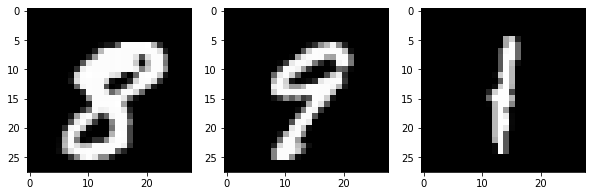

In [5]:
RC=RingCounter()
plt.figure(figsize=(10,6))
for n,i in enumerate(range(10,10+3)):
    plt.subplot(1,3,n+1)
    array=np.array(train.iloc[i,1:])
    print('Recognizer result:',RC.recognizer(array))
    print('Label:',train.iloc[i,0])
    print('\n')
    plt.imshow(array.reshape(28,28),cmap='gray')

The result shows that it has correctly counted the number of rings (8->2, 9->1, 1->0)

I would really appreciate it if you give me any feedbacks!